# **Analysis Workflow: Nigeria Power Generation 2023-2024**
# *AltSchool Africa Data Science Second Semester Capstone Project*

### Setting up

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Loading Clean Data Saved from `Emmanuel_Olafisoye_data_cleaning_notebook`

In [4]:
df = pd.read_csv('nigeria_power_generation_clean.csv', parse_dates=['date'])

print("Nigeria Power Generation Analysis: 2023-2024")
print(f"Dataset: {len(df)} days")
print(f"Period: {df['date'].min()} to {df['date'].max()}")

df_2023 = df[df['year'] == 2023].copy()
df_2024 = df[df['year'] == 2024].copy()

print(f"\n2023: {len(df_2023)} days") 
print(f"2024: {len(df_2024)} days")

Nigeria Power Generation Analysis: 2023-2024
Dataset: 731 days
Period: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

2023: 365 days
2024: 366 days


### **Question:** Was 2024 Worse Than 2023?

### This is our central question. Descriptive stats give us the first answer.

In [35]:
mean_2023 = df_2023['daily_generation_mwh'].mean()
mean_2024 = df_2024['daily_generation_mwh'].mean()
std_2023  = df_2023['daily_generation_mwh'].std()
std_2024  = df_2024['daily_generation_mwh'].std()
cv_2023   = (std_2023 / mean_2023) * 100
cv_24     = (std_2024 / mean_2024) * 100

print("="*60)
print("CENTRAL QUESTION: WAS 2024 WORSE THAN 2023?")
print("="*60)

print(f"\n2023 Average Generation : {mean_2023:,.2f} MWh")
print(f"2024 Average Generation : {mean_2024:,.2f} MWh")
print(f"Change                  : {mean_2024 - mean_2023:,.2f} MWh  ({((mean_2024/mean_2023 - 1)*100):.2f}%)")

print(f"\n2023 Std Deviation : {std_2023:,.2f} MWh")
print(f"2024 Std Deviation : {std_2024:,.2f} MWh")

print(f"\n2023 Coefficient of Variation : {cv_2023:.2f}%")
print(f"2024 Coefficient of Variation : {cv_24:.2f}%")

# CV tells us about relative unpredictability.
# A higher CV means the grid became less consistent day to day.

CENTRAL QUESTION: WAS 2024 WORSE THAN 2023?

2023 Average Generation : 4,018.62 MWh
2024 Average Generation : 3,674.37 MWh
Change                  : -344.25 MWh  (-8.57%)

2023 Std Deviation : 451.64 MWh
2024 Std Deviation : 580.48 MWh

2023 Coefficient of Variation : 11.24%
2024 Coefficient of Variation : 15.80%


#### We just looked at averages and variability numbers.
#### Before we go further, we need to SEE the raw story.
#### This chart shows the daily output across both years side by side.

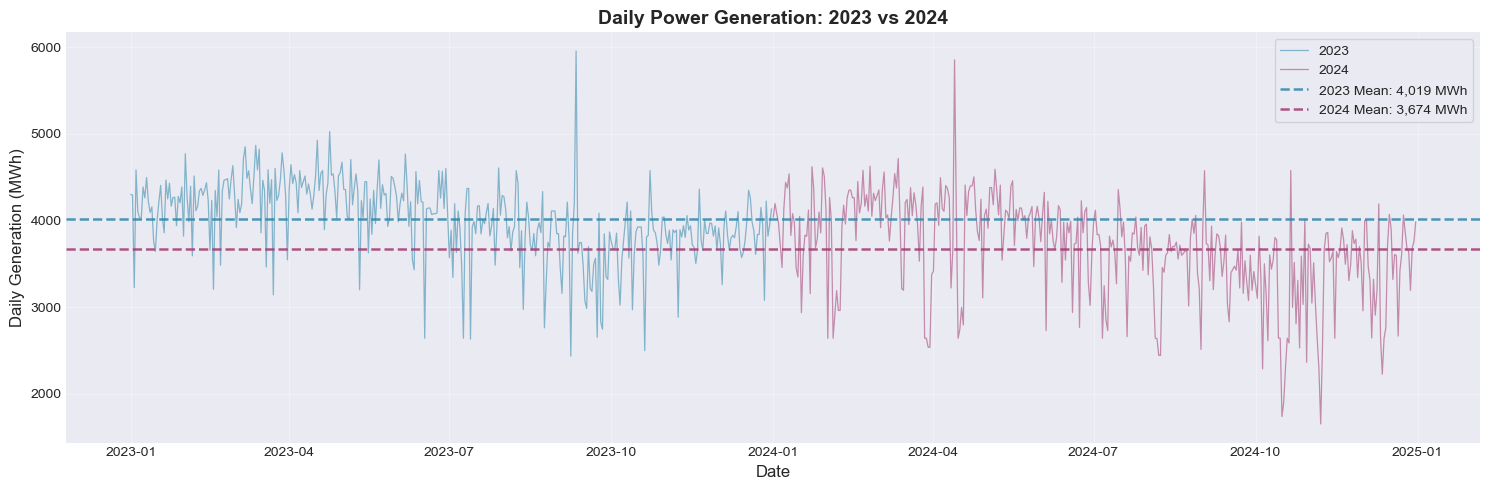

Figure 1 saved.


In [34]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_2023['date'], df_2023['daily_generation_mwh'],
        color='#2E86AB', alpha=0.55, linewidth=0.9, label='2023')
ax.plot(df_2024['date'], df_2024['daily_generation_mwh'],
        color='#A23B72', alpha=0.55, linewidth=0.9, label='2024')

ax.axhline(y=mean_2023, color='#2E86AB', linestyle='--', linewidth=1.8,
           alpha=0.85, label=f'2023 Mean: {mean_2023:,.0f} MWh')
ax.axhline(y=mean_2024, color='#A23B72', linestyle='--', linewidth=1.8,
           alpha=0.85, label=f'2024 Mean: {mean_2024:,.0f} MWh')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Generation (MWh)', fontsize=12)
ax.set_title('Daily Power Generation: 2023 vs 2024', fontsize=14, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_01_daily_generation_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

#### **What this shows:** The two lines trend in the same downward direction, but 2024's line sits visibly lower and swings wider throughout.
#### The dashed lines confirm the 344 MWh gap between averages.

#### Daily data is noisy. A rolling average smooths that noise and reveals the true trend direction underneath the chaos.

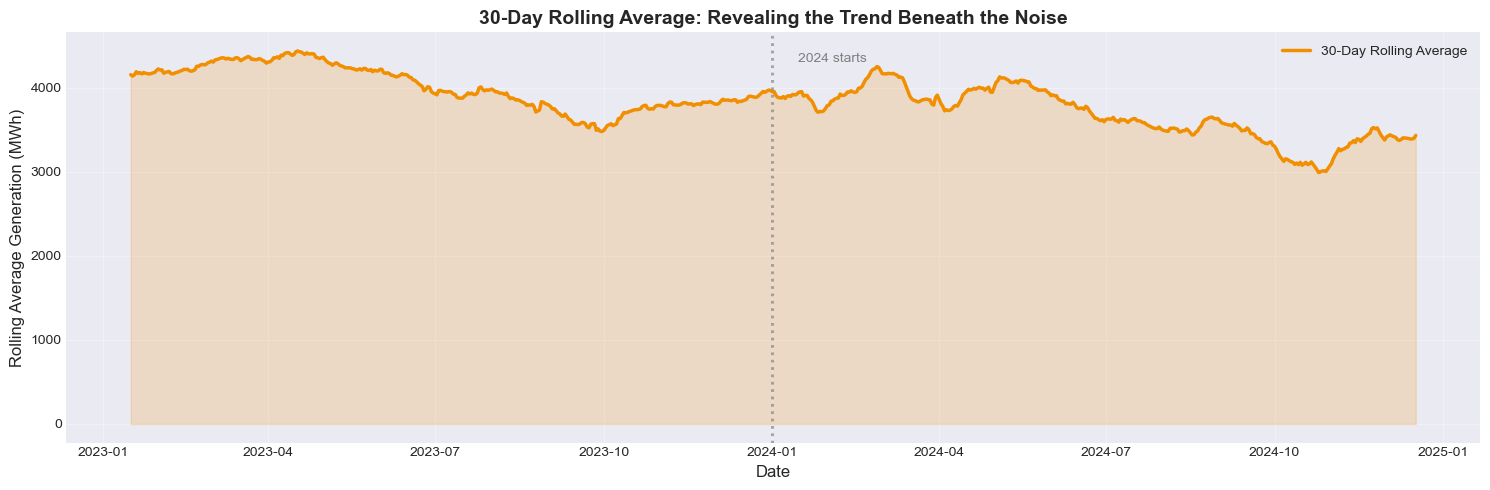

Figure 2 saved.


In [18]:
df['rolling_30d'] = df['daily_generation_mwh'].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(df['date'], df['rolling_30d'], alpha=0.18, color='#F18F01')
ax.plot(df['date'], df['rolling_30d'], color='#F18F01', linewidth=2.5, label='30-Day Rolling Average')

# Mark the year boundary
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.text(pd.Timestamp('2024-01-15'), df['rolling_30d'].max() * 0.97,
        '2024 starts', fontsize=10, color='gray')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rolling Average Generation (MWh)', fontsize=12)
ax.set_title('30-Day Rolling Average: Revealing the Trend Beneath the Noise', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_02_rolling_average_trend.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved.") 

#### **What this shows:** The rolling average exposes a clear downward slope that was hard to see in the noisy daily chart. 

#### The drop accelerates noticeably from mid-2024 onward, especially in Q4.

### Statistical Significance Test
#### Descriptive stats show decline, but is it statistically significant?

In [6]:
# using independent samples t-test to compare means.

t_stat, p_value = stats.ttest_ind(df_2023['daily_generation_mwh'], 
                                    df_2024['daily_generation_mwh'])

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE")
print("="*60)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: STATISTICALLY SIGNIFICANT")
    print("The difference is real, not due to chance.")
else:
    print("\nResult: NOT statistically significant")


STATISTICAL SIGNIFICANCE
t-statistic: 8.9469
p-value: 0.000000

Result: STATISTICALLY SIGNIFICANT
The difference is real, not due to chance.


### Now, we know that statistic is significant. 

#### Let us find how different they (2023 & 2024) are  

In [7]:
# Effect size (Cohen's d) tells us HOW different they are

pooled_std = np.sqrt(((len(df_2023)-1)*std_2023**2 + (len(df_2024)-1)*std_2024**2) / 
                      (len(df_2023)+len(df_2024)-2))
cohens_d = (mean_2023 - mean_2024) / pooled_std
print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
print("Interpretation: " + ("Large" if abs(cohens_d) > 0.5 else "Medium" if abs(cohens_d) > 0.2 else "Small")) 


Effect Size (Cohen's d): 0.6618
Interpretation: Large


### Confidence Intervals

#### let us find a range where the true mean likely falls 

In [23]:
# Confidence intervals give us a range for the true mean.
# If the intervals don't overlap, that's strong evidence the years differ.

ci_2023 = stats.t.interval(0.95, len(df_2023)-1,
                            loc=mean_2023,
                            scale=stats.sem(df_2023['daily_generation_mwh']))
ci_2024 = stats.t.interval(0.95, len(df_2024)-1,
                            loc=mean_2024,
                            scale=stats.sem(df_2024['daily_generation_mwh']))

print("="*60)
print("95% CONFIDENCE INTERVALS")
print("="*60)
print(f"\n2023: [{ci_2023[0]:,.2f},  {ci_2023[1]:,.2f}] MWh")
print(f"2024: [{ci_2024[0]:,.2f},  {ci_2024[1]:,.2f}] MWh")

if ci_2023[0] > ci_2024[1]:
    print("\nNo overlap. The difference between 2023 and 2024 is confirmed.")

95% CONFIDENCE INTERVALS

2023: [3,972.13,  4,065.11] MWh
2024: [3,614.70,  3,734.04] MWh

No overlap. The difference between 2023 and 2024 is confirmed.


#### The statistical tests told us the difference is real.
#### Now we show the shape of each year's distribution and where the means sit.
#### This visual bridges the numbers to the intuition.

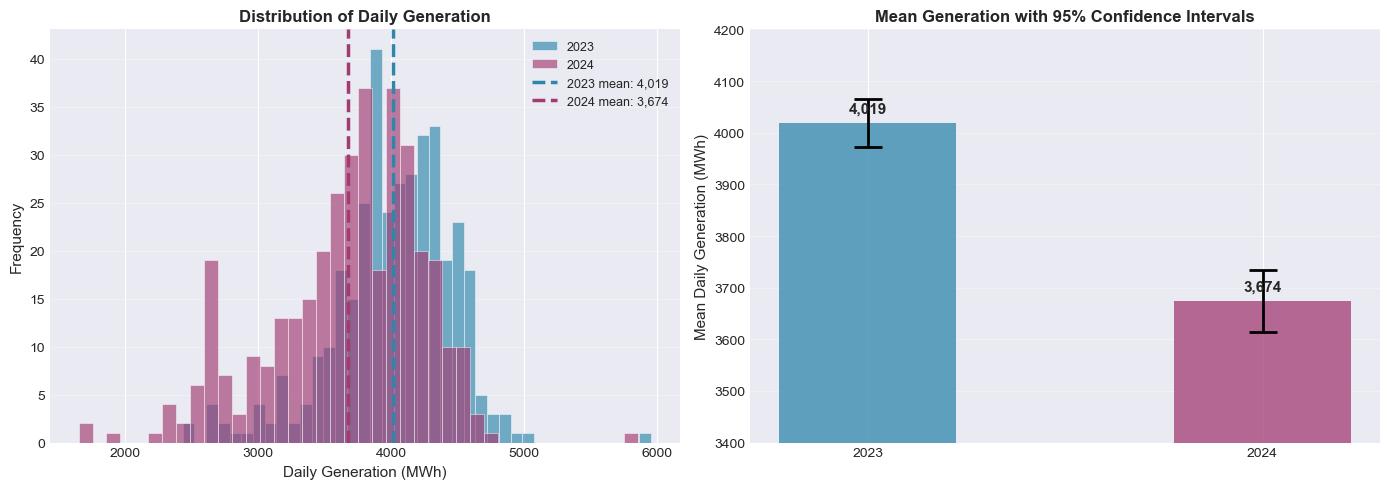

Figure 3 saved.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overlapping histograms
ax = axes[0]
ax.hist(df_2023['daily_generation_mwh'], bins=40, alpha=0.65,
        label='2023', color='#2E86AB', edgecolor='white', linewidth=0.5)
ax.hist(df_2024['daily_generation_mwh'], bins=40, alpha=0.65,
        label='2024', color='#A23B72', edgecolor='white', linewidth=0.5)
ax.axvline(mean_2023, color='#2E86AB', linestyle='--', linewidth=2.5, label=f'2023 mean: {mean_2023:,.0f}')
ax.axvline(mean_2024, color='#A23B72', linestyle='--', linewidth=2.5, label=f'2024 mean: {mean_2024:,.0f}')
ax.set_xlabel('Daily Generation (MWh)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Daily Generation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Right: Confidence interval plot
ax2 = axes[1]
years  = ['2023', '2024']
means  = [mean_2023, mean_2024]
errors = [mean_2023 - ci_2023[0], mean_2024 - ci_2024[0]]
colors = ['#2E86AB', '#A23B72']

bars = ax2.bar(years, means, color=colors, alpha=0.75, width=0.45, zorder=2)
ax2.errorbar(years, means, yerr=errors, fmt='none',
             color='black', capsize=10, capthick=2, elinewidth=2, zorder=3)
ax2.set_ylabel('Mean Daily Generation (MWh)', fontsize=11)
ax2.set_title('Mean Generation with 95% Confidence Intervals', fontsize=12, fontweight='bold')
ax2.set_ylim(3400, 4200)
ax2.grid(True, alpha=0.3, axis='y')
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + 20,
             f'{mean:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_03_distributions_and_ci.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

#### Left panel: 2024's distribution is wider and shifted left.
#### More spread means more unpredictability; leftward shift means less generation.
#### Right panel: The confidence intervals don't touch. No statistical ambiguity.

### Trend Analysis
#### How did generation change over time within each year?

In [21]:
# Year-level averages hide the within-year trajectory.
# We use monthly averages and linear regression to see how fast things declined.

df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month')['daily_generation_mwh'].mean().reset_index()
monthly.columns = ['year_month', 'mean_generation']
monthly['year']  = monthly['year_month'].dt.year
monthly['month'] = monthly['year_month'].dt.month
monthly['year_month'] = monthly['year_month'].dt.to_timestamp()

monthly_2023 = monthly[monthly['year'] == 2023].copy()
monthly_2024 = monthly[monthly['year'] == 2024].copy()

x_2023 = np.arange(len(monthly_2023))
x_2024 = np.arange(len(monthly_2024))

slope_2023, intercept_2023, r_2023, p_2023, _ = linregress(x_2023, monthly_2023['mean_generation'])
slope_2024, intercept_2024, r_2024, p_2024, _ = linregress(x_2024, monthly_2024['mean_generation'])

print("="*60)
print("TREND ANALYSIS: Monthly Decline Rate")
print("="*60)

print(f"\n2023 slope : {slope_2023:.2f} MWh/month")
print(f"2023 R²    : {r_2023**2:.4f}  (how well the line fits)")

print(f"\n2024 slope : {slope_2024:.2f} MWh/month")
print(f"2024 R²    : {r_2024**2:.4f}")

if slope_2024 < slope_2023:
    print(f"\nThe decline accelerated in 2024 by {abs(slope_2024 - slope_2023):.1f} MWh/month")

TREND ANALYSIS: Monthly Decline Rate

2023 slope : -58.88 MWh/month
2023 R²    : 0.6288  (how well the line fits)

2024 slope : -72.19 MWh/month
2024 R²    : 0.7359

The decline accelerated in 2024 by 13.3 MWh/month


#### The regression slopes above are numbers. This chart makes them visible.
#### We plot monthly averages and overlay the fitted trend lines for both years.

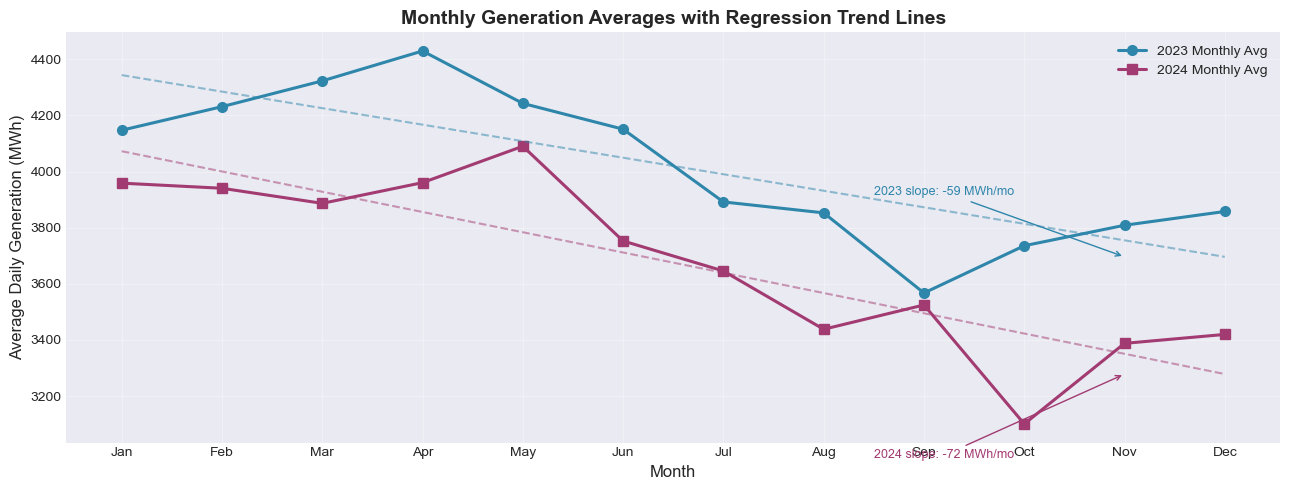

Figure 4 saved.


In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_2023['month'], monthly_2023['mean_generation'],
        'o-', color='#2E86AB', linewidth=2.2, markersize=7, label='2023 Monthly Avg')
ax.plot(monthly_2024['month'], monthly_2024['mean_generation'],
        's-', color='#A23B72', linewidth=2.2, markersize=7, label='2024 Monthly Avg')

# Trend lines from regression
trend_2023 = intercept_2023 + slope_2023 * x_2023
trend_2024 = intercept_2024 + slope_2024 * x_2024
ax.plot(monthly_2023['month'], trend_2023, '--', color='#2E86AB', alpha=0.5, linewidth=1.5)
ax.plot(monthly_2024['month'], trend_2024, '--', color='#A23B72', alpha=0.5, linewidth=1.5)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Daily Generation (MWh)', fontsize=12)
ax.set_title('Monthly Generation Averages with Regression Trend Lines', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate(f'2023 slope: {slope_2023:.0f} MWh/mo', xy=(11, trend_2023[-1]),
            xytext=(8.5, trend_2023[-1]+220),
            arrowprops=dict(arrowstyle='->', color='#2E86AB'), color='#2E86AB', fontsize=9)
ax.annotate(f'2024 slope: {slope_2024:.0f} MWh/mo', xy=(11, trend_2024[-1]),
            xytext=(8.5, trend_2024[-1]-300),
            arrowprops=dict(arrowstyle='->', color='#A23B72'), color='#A23B72', fontsize=9)

plt.tight_layout()
plt.savefig('fig_04_monthly_trend.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

#### 2023 declined at -59 MWh/month. 2024 declined at -72 MWh/month.
#### Steeper slope, higher R² in 2024 means the deterioration was both faster AND more consistent. This is not a random bad year.

### Seasonal/Quartely Breakdown

In [25]:
quarterly = df.groupby(['year', 'quarter'])['daily_generation_mwh'].agg(
    mean_gen = ('mean'),
    std_gen  = ('std')
).reset_index()

print("="*60)
print("QUARTERLY PERFORMANCE")
print("="*60)
for yr in [2023, 2024]:
    print(f"\n{yr}:")
    for _, row in quarterly[quarterly['year'] == yr].iterrows():
        print(f"  Q{int(row['quarter'])}: {row['mean_gen']:,.0f} MWh avg  (σ = {row['std_gen']:,.0f})")

best_month  = monthly.loc[monthly['mean_generation'].idxmax()]
worst_month = monthly.loc[monthly['mean_generation'].idxmin()]
print(f"\nBest month overall  : {best_month['year_month'].strftime('%B %Y')}  ({best_month['mean_generation']:,.0f} MWh)")
print(f"Worst month overall : {worst_month['year_month'].strftime('%B %Y')}  ({worst_month['mean_generation']:,.0f} MWh)")

QUARTERLY PERFORMANCE

2023:
  Q1: 4,234 MWh avg  (σ = 356)
  Q2: 4,274 MWh avg  (σ = 340)
  Q3: 3,773 MWh avg  (σ = 513)
  Q4: 3,801 MWh avg  (σ = 309)

2024:
  Q1: 3,928 MWh avg  (σ = 543)
  Q2: 3,936 MWh avg  (σ = 496)
  Q3: 3,536 MWh avg  (σ = 423)
  Q4: 3,302 MWh avg  (σ = 588)

Best month overall  : April 2023  (4,430 MWh)
Worst month overall : October 2024  (3,101 MWh)


#### The numbers above show quarter-by-quarter performance.
#### The bar chart makes the year-over-year comparison immediately obvious.

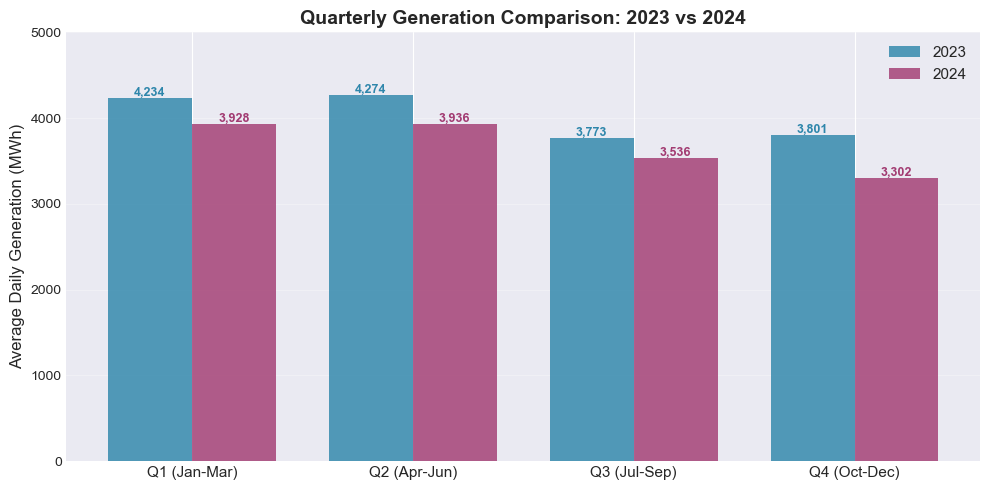

Figure 5 saved.


In [36]:
q_2023 = quarterly[quarterly['year'] == 2023]
q_2024 = quarterly[quarterly['year'] == 2024]

fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(1, 5)
width  = 0.38
bars_a = ax.bar(x - width/2, q_2023['mean_gen'], width,
                label='2023', color='#2E86AB', alpha=0.82)
bars_b = ax.bar(x + width/2, q_2024['mean_gen'], width,
                label='2024', color='#A23B72', alpha=0.82)

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9, color='#2E86AB', fontweight='bold')
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9, color='#A23B72', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)'], fontsize=11)
ax.set_ylabel('Average Daily Generation (MWh)', fontsize=12)
ax.set_title('Quarterly Generation Comparison: 2023 vs 2024', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 5000)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_05_quarterly_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

#### Every single quarter in 2024 underperforms its 2023 equivalent.
#### The gap widens as the year progresses.

#### **Q4 2024 is the disaster: 3,302 MWh vs 3,801 MWh in Q4 2023. That's a 13% additional drop in the final quarter alone.**

### Demand Gap Analysis
#### How much are we failing to meet demand?

In [10]:
avg_gap_2023 = df_2023['generation_demand_gap'].mean()
avg_gap_2024 = df_2024['generation_demand_gap'].mean()

print("\n" + "="*60)
print("GENERATION-DEMAND GAP")
print("="*60)
print(f"2023 Average Gap: {avg_gap_2023:.2f} MWh")
print(f"2024 Average Gap: {avg_gap_2024:.2f} MWh")
print(f"Change: {avg_gap_2024 - avg_gap_2023:.2f} MWh")

pct_gap_2023 = (avg_gap_2023 / df_2023['peak_demand_mwh'].mean()) * 100
pct_gap_2024 = (avg_gap_2024 / df_2024['peak_demand_mwh'].mean()) * 100

print(f"\nAs % of demand:")
print(f"2023: {pct_gap_2023:.1f}% shortfall")
print(f"2024: {pct_gap_2024:.1f}% shortfall") 


GENERATION-DEMAND GAP
2023 Average Gap: 1811.53 MWh
2024 Average Gap: 1557.47 MWh
Change: -254.06 MWh

As % of demand:
2023: 31.1% shortfall
2024: 29.8% shortfall


#### The gap narrowed slightly on average, but severe gap days more than doubled.
#### This is the important nuance: average looks better, extremes got worse.

### Grid Stability Analysis
#### How often were frequency and voltage out of safe ranges?

In [11]:
freq_issues_2023 = df_2023['frequency_out_of_range'].sum()
freq_issues_2024 = df_2024['frequency_out_of_range'].sum()

print("\n" + "="*60)
print("GRID STABILITY")
print("="*60)
print(f"Days with frequency issues:")
print(f"2023: {freq_issues_2023} ({(freq_issues_2023/len(df_2023)*100):.1f}%)")
print(f"2024: {freq_issues_2024} ({(freq_issues_2024/len(df_2024)*100):.1f}%)")

volt_issues_2023 = df_2023['voltage_out_of_range'].sum()
volt_issues_2024 = df_2024['voltage_out_of_range'].sum()

print(f"\nDays with voltage issues:")
print(f"2023: {volt_issues_2023} ({(volt_issues_2023/len(df_2023)*100):.1f}%)")
print(f"2024: {volt_issues_2024} ({(volt_issues_2024/len(df_2024)*100):.1f}%)") 


GRID STABILITY
Days with frequency issues:
2023: 156 (42.7%)
2024: 179 (48.9%)

Days with voltage issues:
2023: 113 (31.0%)
2024: 116 (31.7%)


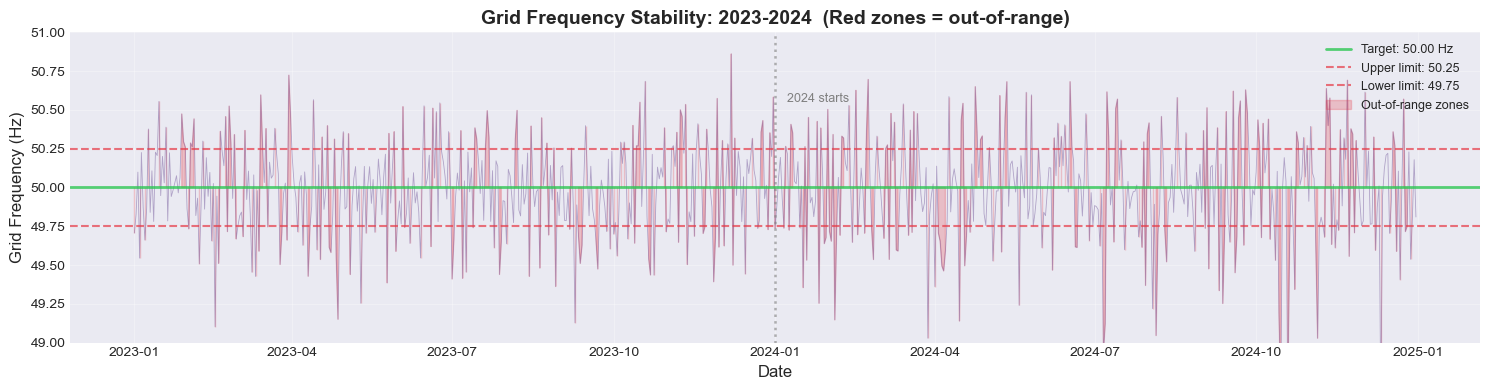

Figure 6 saved.


In [26]:
# Grid frequency is a sensitive diagnostic.
# When frequency drifts from 50 Hz, equipment is under stress.
# This chart shows how often and how far we drifted across both years.

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(df['date'], df['grid_frequency_hz'],
        alpha=0.45, linewidth=0.6, color='#6A4C93')
ax.axhline(50.0,  color='#2DC653', linestyle='-',  linewidth=2,   label='Target: 50.00 Hz', alpha=0.8)
ax.axhline(50.25, color='#E63946', linestyle='--', linewidth=1.5, label='Upper limit: 50.25', alpha=0.7)
ax.axhline(49.75, color='#E63946', linestyle='--', linewidth=1.5, label='Lower limit: 49.75', alpha=0.7)

ax.fill_between(df['date'],
                df['grid_frequency_hz'],
                50.0,
                where=(df['grid_frequency_hz'] < 49.75) | (df['grid_frequency_hz'] > 50.25),
                color='#E63946', alpha=0.25, label='Out-of-range zones')

ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.8, alpha=0.6)
ax.text(pd.Timestamp('2024-01-08'), 50.55, '2024 starts', fontsize=9, color='gray')

ax.set_ylim(49.0, 51.0)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Grid Frequency (Hz)', fontsize=12)
ax.set_title('Grid Frequency Stability: 2023-2024  (Red zones = out-of-range)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_06_grid_frequency.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

#### Red zones represent days when the grid was operating outside safe frequency bounds.
#### In 2024, this happened on 179 days. Nearly 49% of the year.
#### When frequency is consistently off target, cascading failures become more likely.

### Anomaly Detection
#### Identify extreme days using z-scores

In [28]:
# Z-scores flag values that are statistically extreme.
# In power systems, extreme low values often correspond to grid collapses.

z_scores  = np.abs(stats.zscore(df['daily_generation_mwh']))
anomalies = z_scores > 2.5

df['z_score'] = z_scores
df['is_anomaly'] = anomalies

anomaly_df = df[anomalies].copy()

print("="*60)
print("ANOMALY DETECTION (z-score > 2.5)")
print("="*60)
print(f"\nTotal anomalous days: {len(anomaly_df)}")
print(f"2023: {len(anomaly_df[anomaly_df['year'] == 2023])}")
print(f"2024: {len(anomaly_df[anomaly_df['year'] == 2024])}")

print("\nWorst 5 days (lowest generation):")
worst = df.nsmallest(5, 'daily_generation_mwh')[['date','daily_generation_mwh','z_score']]
for _, row in worst.iterrows():
    print(f"  {row['date'].strftime('%Y-%m-%d')} : {row['daily_generation_mwh']:,.0f} MWh   (z = {row['z_score']:.2f})")


ANOMALY DETECTION (z-score > 2.5)

Total anomalous days: 13
2023: 2
2024: 11

Worst 5 days (lowest generation):
  2024-11-07 : 1,650 MWh   (z = 4.01)
  2024-10-16 : 1,735 MWh   (z = 3.86)
  2024-10-17 : 1,903 MWh   (z = 3.55)
  2024-12-12 : 2,224 MWh   (z = 2.96)
  2024-11-06 : 2,286 MWh   (z = 2.85)


#### We detected anomalies statistically. 

#### Now we mark them on the time series so we can see exactly when the worst collapses occurred and whether they cluster in one period.

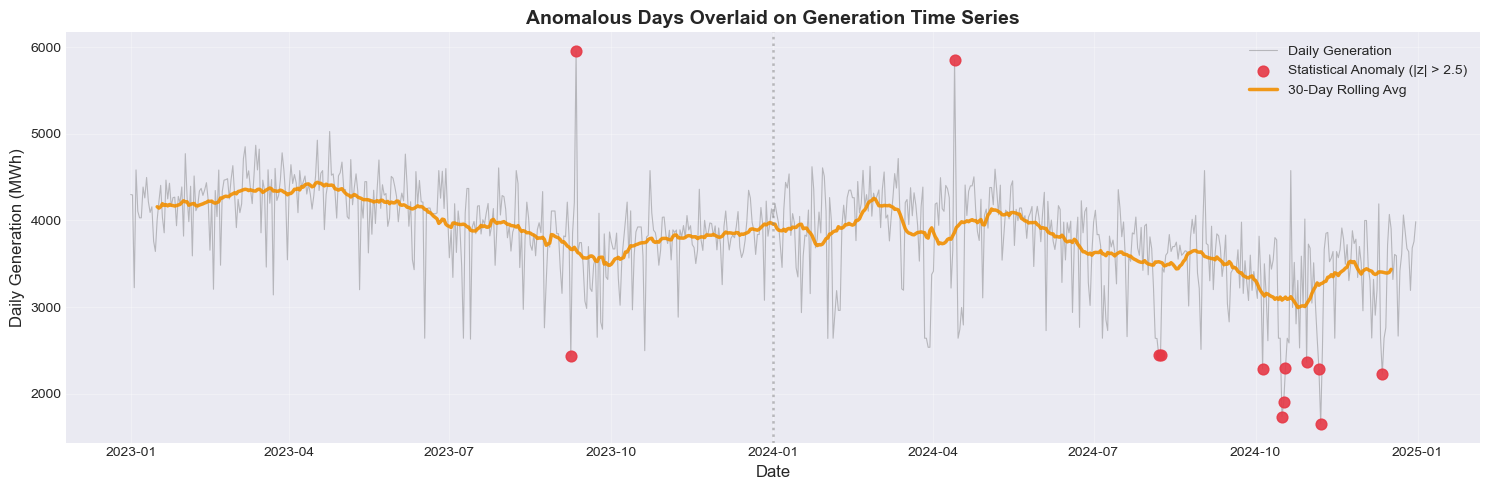

Figure 7 saved.


In [29]:
fig, ax = plt.subplots(figsize=(15, 5))

# Background time series
ax.plot(df['date'], df['daily_generation_mwh'],
        color='#555555', alpha=0.35, linewidth=0.8, label='Daily Generation')

# Highlight anomalies
normal_mask  = ~df['is_anomaly']
anomaly_mask = df['is_anomaly']
ax.scatter(df.loc[anomaly_mask, 'date'],
           df.loc[anomaly_mask, 'daily_generation_mwh'],
           color='#E63946', s=60, zorder=5, label='Statistical Anomaly (|z| > 2.5)', alpha=0.9)

# Rolling average on top for trend context
ax.plot(df['date'], df['rolling_30d'],
        color='#F18F01', linewidth=2.5, label='30-Day Rolling Avg', alpha=0.9)

ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.8, alpha=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Generation (MWh)', fontsize=12)
ax.set_title('Anomalous Days Overlaid on Generation Time Series', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_07_anomalies_overlay.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

#### The red dots are not spread evenly. They cluster in the second half of 2024, particularly Q4. 11 of the 13 anomalous days are in 2024.
#### This is not random. Something structural changed in the second half of 2024.

### Cummulative Generation - The widening Gap

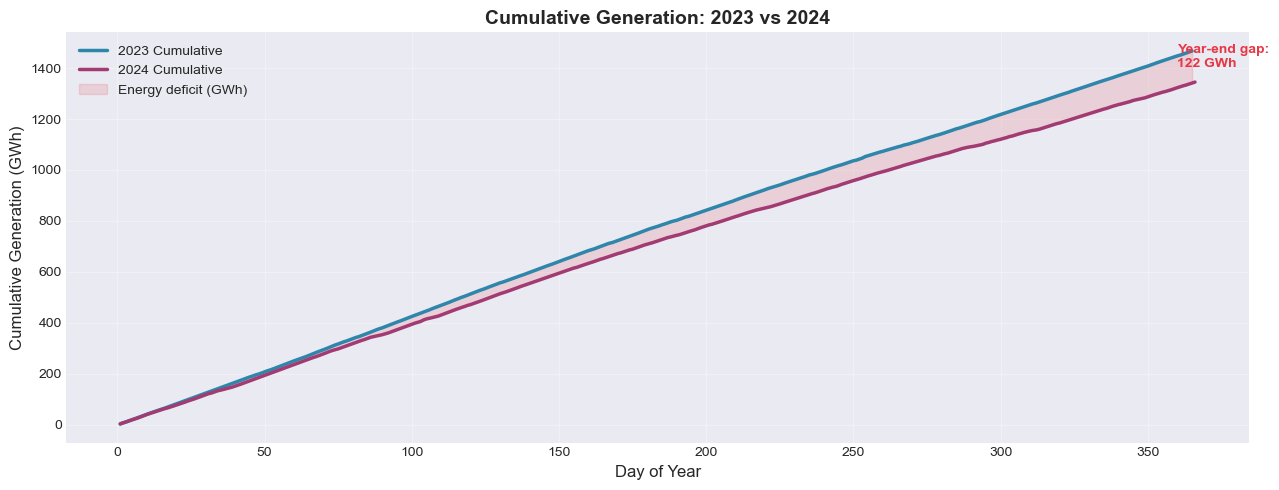

Figure 8 saved.


In [30]:
# Cumulative sums show the total energy delivered over the year.
# The growing gap between 2023 and 2024 lines shows how much energy the country did not receive relative to the previous year.

fig, ax = plt.subplots(figsize=(13, 5))

cumsum_2023 = df_2023.sort_values('date')['daily_generation_mwh'].cumsum() / 1000
cumsum_2024 = df_2024.sort_values('date')['daily_generation_mwh'].cumsum() / 1000
days_2023   = np.arange(1, len(df_2023) + 1)
days_2024   = np.arange(1, len(df_2024) + 1)

ax.plot(days_2023, cumsum_2023, linewidth=2.5, color='#2E86AB', label='2023 Cumulative')
ax.plot(days_2024, cumsum_2024, linewidth=2.5, color='#A23B72', label='2024 Cumulative')

# Shade the gap
ax.fill_between(days_2023, cumsum_2023, cumsum_2024[:len(cumsum_2023)],
                alpha=0.15, color='#E63946', label='Energy deficit (GWh)')

end_gap = (cumsum_2023.iloc[-1] - cumsum_2024.iloc[-1])
ax.annotate(f'Year-end gap:\n{end_gap:,.0f} GWh',
            xy=(360, cumsum_2024.iloc[-1] + end_gap/2),
            fontsize=10, color='#E63946', fontweight='bold')

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('Cumulative Generation (GWh)', fontsize=12)
ax.set_title('Cumulative Generation: 2023 vs 2024', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_08_cumulative_generation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

#### The shaded area is energy that was demanded but not delivered.
#### It compounds throughout the year, growing faster in H2 2024.

### Box Plot - Spread and Outliers by Year

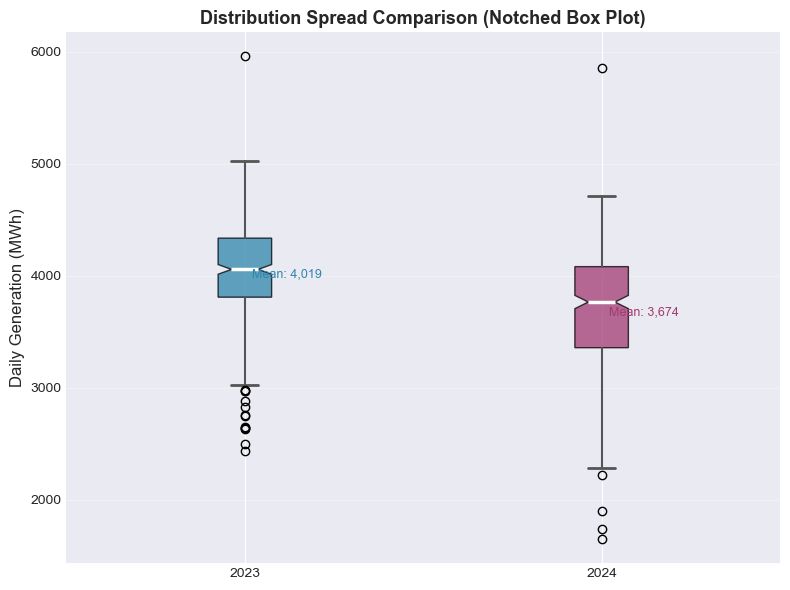

Figure 9 saved.


In [31]:
# A box plot shows the full distribution shape in one view: median, interquartile range, whiskers, and outliers.
# This makes the variability increase visible and comparable.

fig, ax = plt.subplots(figsize=(8, 6))

data_plot = [df_2023['daily_generation_mwh'].values, df_2024['daily_generation_mwh'].values]

bp = ax.boxplot(data_plot, tick_labels=['2023', '2024'],
                patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5))

bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor('#A23B72')
bp['boxes'][1].set_alpha(0.75)

for whisker in bp['whiskers']:
    whisker.set_color('#555555')
    whisker.set_linewidth(1.5)
for cap in bp['caps']:
    cap.set_color('#555555')
    cap.set_linewidth(2)

ax.text(1, mean_2023, f'  Mean: {mean_2023:,.0f}', va='center', fontsize=9, color='#2E86AB')
ax.text(2, mean_2024, f'  Mean: {mean_2024:,.0f}', va='center', fontsize=9, color='#A23B72')

ax.set_ylabel('Daily Generation (MWh)', fontsize=12)
ax.set_title('Distribution Spread Comparison (Notched Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_09_boxplot_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

#### The 2024 box is taller (wider IQR), confirming increased variability.
#### The notches represent confidence intervals around the median.
#### Non-overlapping notches between boxes = statistically different medians.

### Full Analytical Summary

In [32]:
print("="*70)
print("FULL ANALYTICAL SUMMARY")
print("="*70)

print(f"\n2023 mean generation  : {mean_2023:,.2f} MWh")
print(f"2024 mean generation  : {mean_2024:,.2f} MWh")
print(f"Decline               : {mean_2024-mean_2023:,.2f} MWh  ({(mean_2024/mean_2023 - 1)*100:.2f}%)")
print(f"\nStatistical test      : t = {t_stat:.4f},  p = {p_value:.8f}")
print(f"Effect size           : Cohen's d = {cohens_d:.4f}  (large)")
print(f"95% CI 2023           : [{ci_2023[0]:,.1f},  {ci_2023[1]:,.1f}] MWh")
print(f"95% CI 2024           : [{ci_2024[0]:,.1f},  {ci_2024[1]:,.1f}] MWh")
print(f"\n2023 monthly slope    : {slope_2023:.2f} MWh/month  (R²={r_2023**2:.3f})")
print(f"2024 monthly slope    : {slope_2024:.2f} MWh/month  (R²={r_2024**2:.3f})")
print(f"\nFrequency violations  : 2023={freq_issues_2023} days,  2024={freq_issues_2024} days")
print(f"Anomalous days        : 2023={len(anomaly_df[anomaly_df['year']==2023])},  2024={len(anomaly_df[anomaly_df['year']==2024])}")
print(f"\nAll figures created and saved. Analysis complete.")

FULL ANALYTICAL SUMMARY

2023 mean generation  : 4,018.62 MWh
2024 mean generation  : 3,674.37 MWh
Decline               : -344.25 MWh  (-8.57%)

Statistical test      : t = 8.9469,  p = 0.00000000
Effect size           : Cohen's d = 0.6618  (large)
95% CI 2023           : [3,972.1,  4,065.1] MWh
95% CI 2024           : [3,614.7,  3,734.0] MWh

2023 monthly slope    : -58.88 MWh/month  (R²=0.629)
2024 monthly slope    : -72.19 MWh/month  (R²=0.736)

Frequency violations  : 2023=156 days,  2024=179 days
Anomalous days        : 2023=2,  2024=11

All figures created and saved. Analysis complete.


## *Author*

### *Emmanuel Olafisoye* 